In [1]:
import sys
from pathlib import Path
sys.path.append('..')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from src.variables import Var
from src.eda import summarize
from src.data_processing import clean_data

sns.set_theme()
# https://zenodo.org/records/11295916

In [2]:
df = pd.read_parquet('../data/processed/loan_train.parquet')

## Data Information

### Loan Information
| Name | Description | Note |
|---|---|---|
| id | A unique LC assigned ID for the loan listing. | ID |
| issue_d | The month which the loan was funded | Time ID |
| loan_status | Current status of the loan | Target |
| application_type | Indicates whether the loan is an individual application or a joint application with two co-borrowers | |
| policy_code | publicly available policy_code=1, new products not publicly available policy_code=2 | Only policy_code=1 is used | |
| last_pymnt_d | Last month payment was received | |

### Numerical Variables
| Name | Description |
|---|---|
| loan_amnt | The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value. |
| emp_length | Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years. |
| annual_inc | The self-reported annual income provided by the borrower during registration. |
| annual_inc_joint | The combined self-reported annual income provided by the co-borrowers during registration |
| dti | A ratio calculated using the borrower's total monthly debt payments on the total debt obligations, excluding mortgage and the requested LC loan, divided by the borrower's self-reported monthly income. |
| dti_joint | A ratio calculated using the co-borrowers' total monthly payments on the total debt obligations, excluding mortgages and the requested LC loan, divided by the co-borrowers' combined self-reported monthly income |
| fico_range_high | The upper boundary range the borrower's FICO at loan origination belongs to. |
| fico_range_low | The lower boundary range the borrower's FICO at loan origination belongs to. |
| sec_app_fico_range_low | FICO range (high) for the secondary applicant |
| sec_app_fico_range_high | FICO range (low) for the secondary applicant |


### Catagorical Variables
| Name | Description |
|---|---|
| emp_title | The job title supplied by the Borrower when applying for the loan. |
| addr_state | The state provided by the borrower in the loan application |
| home_ownership | The home ownership status provided by the borrower during registration or obtained from the credit report. Our values are: RENT, OWN, MORTGAGE, OTHER |
| purpose | A category provided by the borrower for the loan request. |
| zip_code | The first 3 numbers of the zip code provided by the borrower in the loan application. |


### Time Variables
| Name | Description |
|---|---|
| earliest_cr_line | The month the borrower's earliest reported credit line was opened |
| sec_app_earliest_cr_line | Earliest credit line at time of application for the secondary applicant |


In [3]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df.head())

,loan_amnt,emp_title,emp_length,home_ownership,annual_inc,issue_d,loan_status,purpose,zip_code,addr_state,dti,earliest_cr_line,fico_range_low,fico_range_high,last_pymnt_d,policy_code,application_type,annual_inc_joint,dti_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line
id,,,,,,,,,,,,,,,,,,,,,,
10129454,12000.0,Project Manager,4 years,RENT,60000.0,2013-12,Fully Paid,debt_consolidation,281xx,NC,4.62,2009-12,720.0,724.0,2016-04,1.0,Individual,NaN,NaN,NaN,NaN,NaT
10149488,4800.0,Surgical Technician,2 years,MORTGAGE,39600.0,2013-12,Fully Paid,home_improvement,782xx,TX,2.49,1995-08,755.0,759.0,2014-09,1.0,Individual,NaN,NaN,NaN,NaN,NaT
10149342,27050.0,Team Leadern Customer Ops & Systems,10+ years,OWN,55000.0,2013-12,Fully Paid,debt_consolidation,481xx,MI,22.87,1986-10,730.0,734.0,2016-07,1.0,Individual,NaN,NaN,NaN,NaN,NaT
10148122,12000.0,Systems Engineer,3 years,MORTGAGE,96500.0,2013-12,Fully Paid,debt_consolidation,782xx,TX,12.61,2003-09,705.0,709.0,2016-06,1.0,Individual,NaN,NaN,NaN,NaN,NaT
10129477,14000.0,Assistant Director - Human Resources,4 years,RENT,88000.0,2013-12,Fully Paid,debt_consolidation,282xx,NC,10.02,1988-06,670.0,674.0,2017-01,1.0,Individual,NaN,NaN,NaN,NaN,NaT


In [4]:
df[list(Var.numeric_features)].describe()

,loan_amnt,annual_inc,dti,fico_range_high,fico_range_low,annual_inc_joint,dti_joint,sec_app_fico_range_low,sec_app_fico_range_high
count,1.669524e+06,1.669524e+06,1.668945e+06,1.669524e+06,1.669524e+06,5.172500e+04,51721.000000,39036.000000,39036.000000
mean,1.490829e+04,7.785906e+04,1.878221e+01,6.998120e+02,6.958119e+02,1.173333e+05,19.110441,666.080029,670.080080
std,8.922218e+03,1.209725e+05,1.201070e+01,3.149546e+01,3.149470e+01,5.729587e+04,7.448675,44.271530,44.271738
min,1.000000e+03,0.000000e+00,-1.000000e+00,6.640000e+02,6.600000e+02,1.100000e+04,0.000000,540.000000,544.000000
25%,8.000000e+03,4.700000e+04,1.217000e+01,6.740000e+02,6.700000e+02,8.100000e+04,13.720000,640.000000,644.000000
50%,1.297500e+04,6.500000e+04,1.804000e+01,6.940000e+02,6.900000e+02,1.070000e+05,18.780000,665.000000,669.000000
75%,2.000000e+04,9.300000e+04,2.461000e+01,7.140000e+02,7.100000e+02,1.400000e+05,24.250000,695.000000,699.000000
max,4.000000e+04,1.100000e+08,9.990000e+02,8.500000e+02,8.450000e+02,1.300000e+06,69.490000,845.000000,850.000000


In [5]:
summarize(df)

,dtype,missing,missing_pct,unique,sample
loan_amnt,float64,0,0.000000,1560,12000.0
emp_title,str,106512,6.379783,395173,Project Manager
emp_length,string,101883,6.102518,11,4 years
home_ownership,str,0,0.000000,5,RENT
annual_inc,float64,0,0.000000,74124,60000.0
issue_d,period[M],0,0.000000,60,2013-12
loan_status,str,0,0.000000,7,Fully Paid
purpose,str,0,0.000000,14,debt_consolidation
zip_code,str,1,0.000060,951,281xx
addr_state,str,0,0.000000,51,NC


## Distribution

/var/folders/fh/b4cvq4qx0217_r1fsrg8v59w0000gn/T/ipykernel_2540/2783732995.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(p.get_xticklabels(), rotation=90);


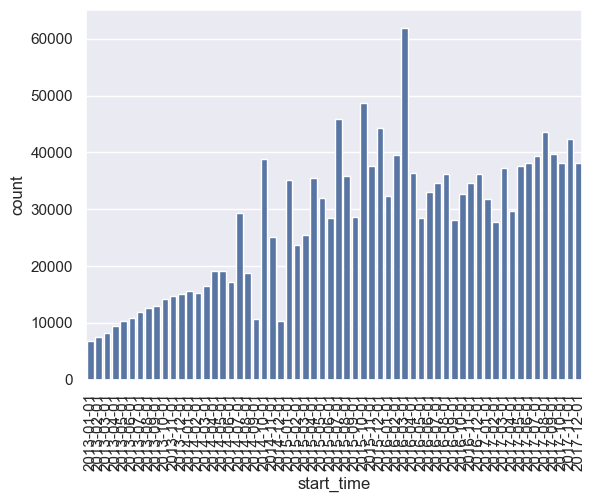

In [6]:
load_by_months = pd.DataFrame(df.value_counts('issue_d')).sort_index()
load_by_months['start_time'] = load_by_months.index.start_time
p = sns.barplot(load_by_months, x='start_time', y='count')
p.set_xticklabels(p.get_xticklabels(), rotation=90);


## Target Variable

From the category of the loan status, we can consider
- 'Fully Paid' as Good loans
- 'Charged Off' and 'Default' as Bad loans
- 'Late (31-120 days)' is optional

We don't take the rest into account.

In [7]:
count_df = pd.DataFrame(df.value_counts('loan_status'))
count_df['percentage'] = (count_df['count'] / count_df['count'].sum() * 100).round(2)
count_df

,count,percentage
loan_status,,
Fully Paid,1202925,72.05
Charged Off,287568,17.22
Current,171696,10.28
Late (31-120 days),3871,0.23
In Grace Period,2552,0.15
Late (16-30 days),663,0.04
Default,249,0.01


/var/folders/fh/b4cvq4qx0217_r1fsrg8v59w0000gn/T/ipykernel_2540/3319641767.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p1.set_xticklabels(p1.get_xticklabels(), rotation=90)


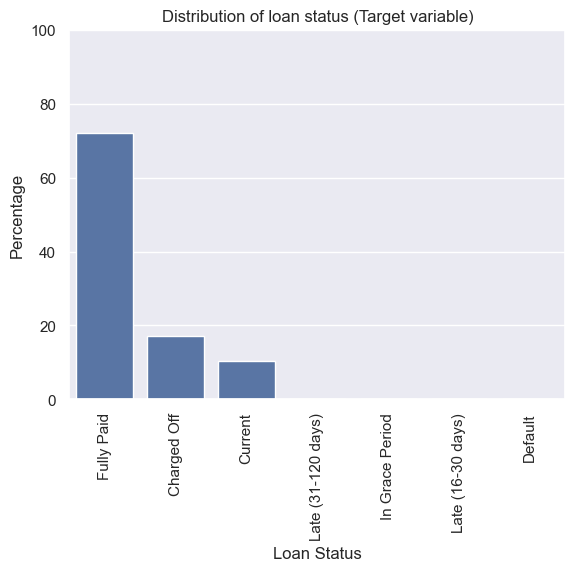

In [8]:
p1 = sns.barplot(
    count_df.reset_index(),
    x='loan_status',
    y='percentage'
)
p1.set_xticklabels(p1.get_xticklabels(), rotation=90)
p1.set_title('Distribution of loan status (Target variable)')
p1.set_xlabel('Loan Status')
p1.set_ylabel('Percentage')
p1.set_ylim(0, 100)
p1;

## Variables

### Loan Amount

Text(0.5, 0, 'Amount (USD)')

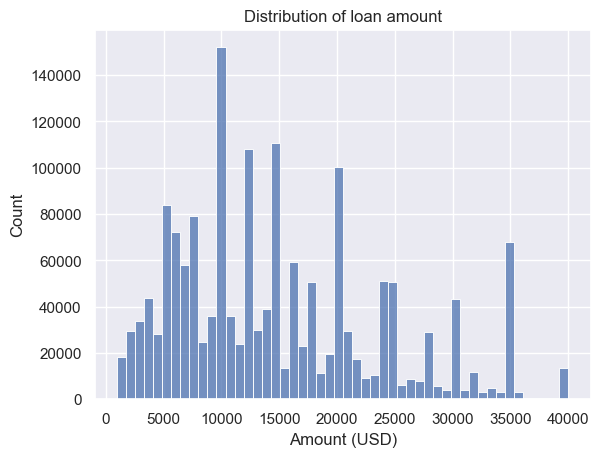

In [9]:
p2 = sns.histplot(
    df['loan_amnt'],
    bins=50,
)
p2.set_title('Distribution of loan amount')
p2.set_xlabel('Amount (USD)')

### FICO Score Difference

In [10]:
fico_diff = df['fico_range_high'] - df['fico_range_low']

In [11]:
fico_diff.value_counts()

4.0    1669258
5.0        266
Name: count, dtype: int64

### Years of Employment

/var/folders/fh/b4cvq4qx0217_r1fsrg8v59w0000gn/T/ipykernel_2540/3615259837.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p3.set_xticklabels(p3.get_xticklabels(), rotation=90)


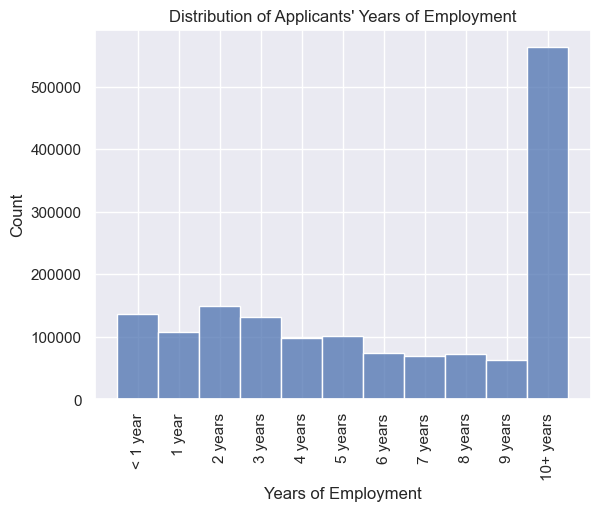

In [ ]:
emp_length = pd.Categorical(
    df['emp_length'],
    categories=[
        '< 1 year',
        '1 year',
        *[f'{i} years' for i in range(2, 10)],
        '10+ years'
    ],
    ordered=True
)
p3 = sns.histplot(
    emp_length
)
p3.set_xticklabels(p3.get_xticklabels(), rotation=90)
p3.set_title('Distribution of Applicants\' Years of Employment')
p3.set_xlabel('Years of Employment')
p3;

### Application Type

In [13]:
df['application_type'].value_counts()

application_type
Individual    1617799
Joint App       51725
Name: count, dtype: int64

### Joint Loan

In [14]:
joint_loan_mask = df['application_type'] == 'Joint App'

In [15]:
df[joint_loan_mask]['annual_inc_joint'].isna().sum()

np.int64(0)

In [16]:
df[joint_loan_mask]['dti_joint'].isna().sum()

np.int64(4)

In [17]:
df[joint_loan_mask][df[joint_loan_mask]['dti_joint'].isna()].T

id,66485064,65098814,73333161,71296957
loan_amnt,15000.0,18000.0,16925.0,5500.0
emp_title,fork lift driver,Automotive Armor Trim Tech,Dining room manager,Coordinator
emp_length,10+ years,8 years,10+ years,2 years
home_ownership,RENT,MORTGAGE,RENT,MORTGAGE
annual_inc,44000.0,44720.0,50000.0,24000.0
issue_d,2015-12,2015-11,2016-03,2016-02
loan_status,Current,Fully Paid,Fully Paid,Fully Paid
purpose,debt_consolidation,debt_consolidation,debt_consolidation,debt_consolidation
zip_code,973xx,331xx,945xx,296xx
addr_state,OR,FL,CA,SC


In [18]:
df[df['dti'].isna()].iloc[:5, :15]

,loan_amnt,emp_title,emp_length,home_ownership,annual_inc,issue_d,loan_status,purpose,zip_code,addr_state,dti,earliest_cr_line,fico_range_low,fico_range_high,last_pymnt_d
id,,,,,,,,,,,,,,,
120109011,7500.0,NaN,<NA>,MORTGAGE,0.0,2017-09,Fully Paid,debt_consolidation,231xx,VA,NaN,2007-05,680.0,684.0,2018-07
120071204,35000.0,NaN,<NA>,MORTGAGE,0.0,2017-09,Current,debt_consolidation,344xx,FL,NaN,2004-11,715.0,719.0,2020-05
120112121,5000.0,NaN,<NA>,MORTGAGE,0.0,2017-09,Fully Paid,home_improvement,457xx,OH,NaN,2008-09,725.0,729.0,2020-04
119991231,5000.0,NaN,<NA>,MORTGAGE,0.0,2017-09,Fully Paid,home_improvement,782xx,TX,NaN,1991-06,705.0,709.0,2018-04
119217495,35000.0,NaN,<NA>,RENT,0.0,2017-09,Fully Paid,other,926xx,CA,NaN,2000-05,795.0,799.0,2019-01


### Home Ownership

In [27]:
df.value_counts('home_ownership')

home_ownership
MORTGAGE    828324
RENT        655213
OWN         185475
ANY            508
NONE             4
Name: count, dtype: int64

## Cleaned Data

In [19]:
df.iloc[81]

loan_amnt                        9450.0
emp_title                           NaN
emp_length                         <NA>
home_ownership                     RENT
annual_inc                      21900.0
issue_d                         2013-12
loan_status                 Charged Off
purpose                     credit_card
zip_code                          437xx
addr_state                           OH
dti                               17.26
earliest_cr_line                2007-04
fico_range_low                    695.0
fico_range_high                   699.0
last_pymnt_d                    2016-10
policy_code                         1.0
application_type             Individual
annual_inc_joint                    NaN
dti_joint                           NaN
sec_app_fico_range_low              NaN
sec_app_fico_range_high             NaN
sec_app_earliest_cr_line            NaT
Name: 10149363, dtype: object

In [20]:
np.isnan(df.iloc[81].emp_length)

<NA>

In [21]:
from src.data_processing import handle_employment_years
handle_employment_years(df.iloc[80:85])

,loan_amnt,emp_title,emp_length,home_ownership,annual_inc,issue_d,loan_status,purpose,zip_code,addr_state,...,fico_range_low,fico_range_high,last_pymnt_d,policy_code,application_type,annual_inc_joint,dti_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line
id,,,,,,,,,,,,,,,,,,,,,
10109417,13000.0,Police officer,10,MORTGAGE,102120.0,2013-12,Fully Paid,home_improvement,781xx,TX,...,710.0,714.0,2014-02,1.0,Individual,NaN,NaN,NaN,NaN,NaT
10149363,9450.0,NaN,0,RENT,21900.0,2013-12,Charged Off,credit_card,437xx,OH,...,695.0,699.0,2016-10,1.0,Individual,NaN,NaN,NaN,NaN,NaT
10149332,23675.0,ultrasound tech,1,OWN,54000.0,2013-12,Charged Off,credit_card,762xx,TX,...,675.0,679.0,2015-06,1.0,Individual,NaN,NaN,NaN,NaN,NaT
10099391,14000.0,Case Manager,10,MORTGAGE,74628.0,2013-12,Fully Paid,debt_consolidation,755xx,TX,...,775.0,779.0,2014-06,1.0,Individual,NaN,NaN,NaN,NaN,NaT
10119464,30000.0,Sales/Finance,2,RENT,85000.0,2013-12,Fully Paid,credit_card,981xx,WA,...,660.0,664.0,2017-01,1.0,Individual,NaN,NaN,NaN,NaN,NaT


In [22]:
cleaned_df = clean_data(df)

In [23]:
cleaned_df['emp_length'].value_counts()

emp_length
10    500870
1     217322
2     134528
3     118962
5      90709
0      90577
4      87586
6      67285
8      66082
7      63435
9      57257
Name: count, dtype: int64

In [24]:
cleaned_df[['loan_amnt', 'emp_length', 'annual_inc', 'dti', 'fico']].corr()

,loan_amnt,emp_length,annual_inc,dti,fico
loan_amnt,1.000000,0.110162,0.189338,0.023101,0.111075
emp_length,0.110162,1.000000,0.050906,0.014259,0.016701
annual_inc,0.189338,0.050906,1.000000,-0.095851,0.045461
dti,0.023101,0.014259,-0.095851,1.000000,-0.058158
fico,0.111075,0.016701,0.045461,-0.058158,1.000000


/var/folders/fh/b4cvq4qx0217_r1fsrg8v59w0000gn/T/ipykernel_2540/782346313.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(p.get_xticklabels(), rotation=90)


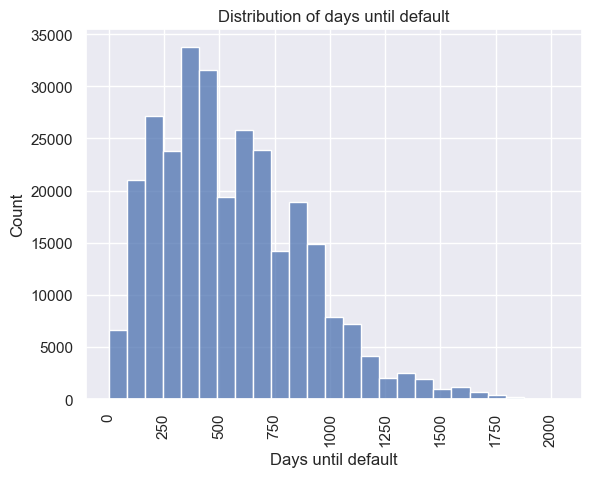

In [49]:
default_mask = cleaned_df['default'] == 1
time_until_default = (cleaned_df[default_mask]['last_pymnt_d'].dt.start_time - cleaned_df[default_mask]['issue_d'].dt.start_time).dt.days
p = sns.histplot(time_until_default, bins=25)
p.set_xticklabels(p.get_xticklabels(), rotation=90)
p.set_title('Distribution of days until default')
p.set_xlabel('Days until default')
p;